In [2]:
import numpy as np
import pandas as pd
from scipy.stats import t, friedmanchisquare


def bootstrap_accuracy_ci_from_runs(
    df_agg: pd.DataFrame,
    n_boot: int = 2000,
    ci: float = 95,
    random_state: int = 42,
):
    """
    df_agg: DataFrame loaded from a *_multi_run.jsonl file
            Must contain a 'runs' column, with one row per case
    Returns:
        mean_accuracy, ci_low, ci_high
    """

    rng = np.random.default_rng(random_state)

    # Each case becomes one row, and each run becomes one decision (0/1) column
    decisions = []
    num_runs = max(len(runs) for runs in df_agg["runs"])

    for _, row in df_agg.iterrows():
        run_decisions = []
        runs = row["runs"]

        for i in range(num_runs):
            if i < len(runs) and isinstance(runs[i], dict):
                val = runs[i].get("effective_decision", runs[i].get("decision", None))
                run_decisions.append(np.nan if val is None else float(bool(val)))
            else:
                run_decisions.append(np.nan)

        decisions.append(run_decisions)

    decision_matrix = np.array(decisions, dtype=float)   # shape: (n_cases, n_runs)
    n_cases = decision_matrix.shape[0]

    # Raw mean accuracy: calculate accuracy for each run, then average across runs
    run_accs = np.nanmean(decision_matrix, axis=0)
    mean_accuracy = float(np.nanmean(run_accs) * 100)

    accuracy_sd = float(np.nanstd(run_accs * 100, ddof=1)) if np.sum(~np.isnan(run_accs)) > 1 else 0.0

    boot_means = []
    for _ in range(n_boot):
        sample_idx = rng.integers(0, n_cases, size=n_cases)
        sampled = decision_matrix[sample_idx, :]
        sampled_run_accs = np.nanmean(sampled, axis=0)
        boot_means.append(np.nanmean(sampled_run_accs) * 100)

    alpha = (100 - ci) / 2
    ci_low = float(np.percentile(boot_means, alpha))
    ci_high = float(np.percentile(boot_means, 100 - alpha))

    return mean_accuracy, accuracy_sd, ci_low, ci_high


def load_model_summary_with_case_bootstrap(model_label, raw_dir):
    rows = []

    for internal_name in ALL_DATASETS:
        agg_file_path = os.path.join(raw_dir, f"{internal_name}_multi_run.jsonl")
        if not os.path.exists(agg_file_path):
            continue

        df_agg = pd.read_json(agg_file_path, lines=True)
        if df_agg.empty or "runs" not in df_agg.columns:
            continue

        mean_acc, accuracy_sd, ci_low, ci_high = bootstrap_accuracy_ci_from_runs(df_agg)

        rows.append({
            "Dataset": DATASET_NAME_MAP[internal_name],
            "Model": model_label,
            "Accuracy_mean": mean_acc,
            "Accuracy_sd": accuracy_sd,
            "CI95_low": ci_low,
            "CI95_high": ci_high,
        })

    # Overall
    all_agg_dfs = []
    for internal_name in ALL_DATASETS:
        fp = os.path.join(raw_dir, f"{internal_name}_multi_run.jsonl")
        if os.path.exists(fp):
            all_agg_dfs.append(pd.read_json(fp, lines=True))

    if all_agg_dfs:
        df_overall = pd.concat(all_agg_dfs, ignore_index=True)
        mean_acc, accuracy_sd, ci_low, ci_high = bootstrap_accuracy_ci_from_runs(df_overall)
        rows.append({
            "Dataset": "Overall",
            "Model": model_label,
            "Accuracy_mean": mean_acc,
            "Accuracy_sd": accuracy_sd,
            "CI95_low": ci_low,
            "CI95_high": ci_high,
        })

    return pd.DataFrame(rows)


from scipy.stats import wilcoxon

def _case_mean_correct_by_dataset(raw_dir, internal_name, decision_key="decision"):
    fp = os.path.join(raw_dir, f"{internal_name}_multi_run.jsonl")
    if not os.path.exists(fp):
        return pd.DataFrame()

    df = pd.read_json(fp, lines=True)
    if df.empty or "runs" not in df.columns:
        return pd.DataFrame()

    rows = []
    for _, row in df.iterrows():
        vals = []
        for run in row["runs"]:
            if isinstance(run, dict):
                vals.append(np.nan if run.get(decision_key) is None else float(bool(run.get("effective_decision", run.get(decision_key, None)))))
        rows.append({
            "case_id": f"{internal_name}__{row.get('hadm_id')}",
            "Dataset": DATASET_NAME_MAP[internal_name],
            "mean_correct": np.nanmean(vals) if vals else np.nan,
        })

    return pd.DataFrame(rows)


def paired_temperature_comparison(
    dir_a,
    dir_b,
    label_a="T=0.01",
    label_b="T=0.3",
    decision_key="decision",
    n_boot=5000,
    random_state=42,
):
    rng = np.random.default_rng(random_state)

    all_pairs = []

    for internal_name in ALL_DATASETS:
        df_a = _case_mean_correct_by_dataset(dir_a, internal_name, decision_key=decision_key)
        df_b = _case_mean_correct_by_dataset(dir_b, internal_name, decision_key=decision_key)

        if df_a.empty or df_b.empty:
            continue

        merged = df_a.merge(
            df_b,
            on=["case_id", "Dataset"],
            suffixes=("_a", "_b"),
        ).dropna(subset=["mean_correct_a", "mean_correct_b"])

        if merged.empty:
            continue

        merged["diff"] = merged["mean_correct_a"] - merged["mean_correct_b"]
        all_pairs.append(merged)

    if not all_pairs:
        raise ValueError("No paired cases found between the two temperature directories.")

    df_pairs = pd.concat(all_pairs, ignore_index=True)

    diffs = df_pairs["diff"].to_numpy(dtype=float)
    n = len(diffs)

    # Effect size: paired mean accuracy difference in percentage points.
    observed_diff_pp = float(np.mean(diffs) * 100)

    # Paired case-level bootstrap CI.
    boot_diffs = []
    for _ in range(n_boot):
        idx = rng.integers(0, n, size=n)
        boot_diffs.append(np.mean(diffs[idx]) * 100)

    ci_low, ci_high = np.percentile(boot_diffs, [2.5, 97.5])

    # One-sided paired permutation test: H1 = label_a > label_b.
    # Under the null, signs of paired differences are exchangeable.
    perm_stats = []
    for _ in range(n_boot):
        signs = rng.choice([-1, 1], size=n)
        perm_stats.append(np.mean(diffs * signs) * 100)

    p_one_sided = float((np.sum(np.array(perm_stats) >= observed_diff_pp) + 1) / (n_boot + 1))

    # Optional nonparametric paired test for cross-check.
    try:
        wilcoxon_p = wilcoxon(diffs, alternative="greater", zero_method="wilcox").pvalue
    except ValueError:
        wilcoxon_p = np.nan

    result = pd.DataFrame([{
        "Comparison": f"{label_a} - {label_b}",
        "N_cases": n,
        "Accuracy_diff_pp": observed_diff_pp,
        "CI95_low_pp": float(ci_low),
        "CI95_high_pp": float(ci_high),
        "Permutation_p_one_sided": p_one_sided,
        "Wilcoxon_p_one_sided": wilcoxon_p,
    }])

    return result, df_pairs



===== Processing group: GLM-4.5-Air =====
正在加载 N=3 ...
正在加载 N=5 ...
正在加载 N=10 ...
正在计算 bootstrap CI for N=3 ...
正在计算 bootstrap CI for N=5 ...
正在计算 bootstrap CI for N=10 ...
case-level bootstrap CI 汇总已保存到: /mnt/bulk-sirius/lizhang/LiWS/Medical_Llama_Agents/data/plots/63/63.10_N/accuracy_summary_multi_T_bootstrap_CI.csv
多模型分组条形图已保存到: /mnt/bulk-sirius/lizhang/LiWS/Medical_Llama_Agents/data/plots/63/63.10_N


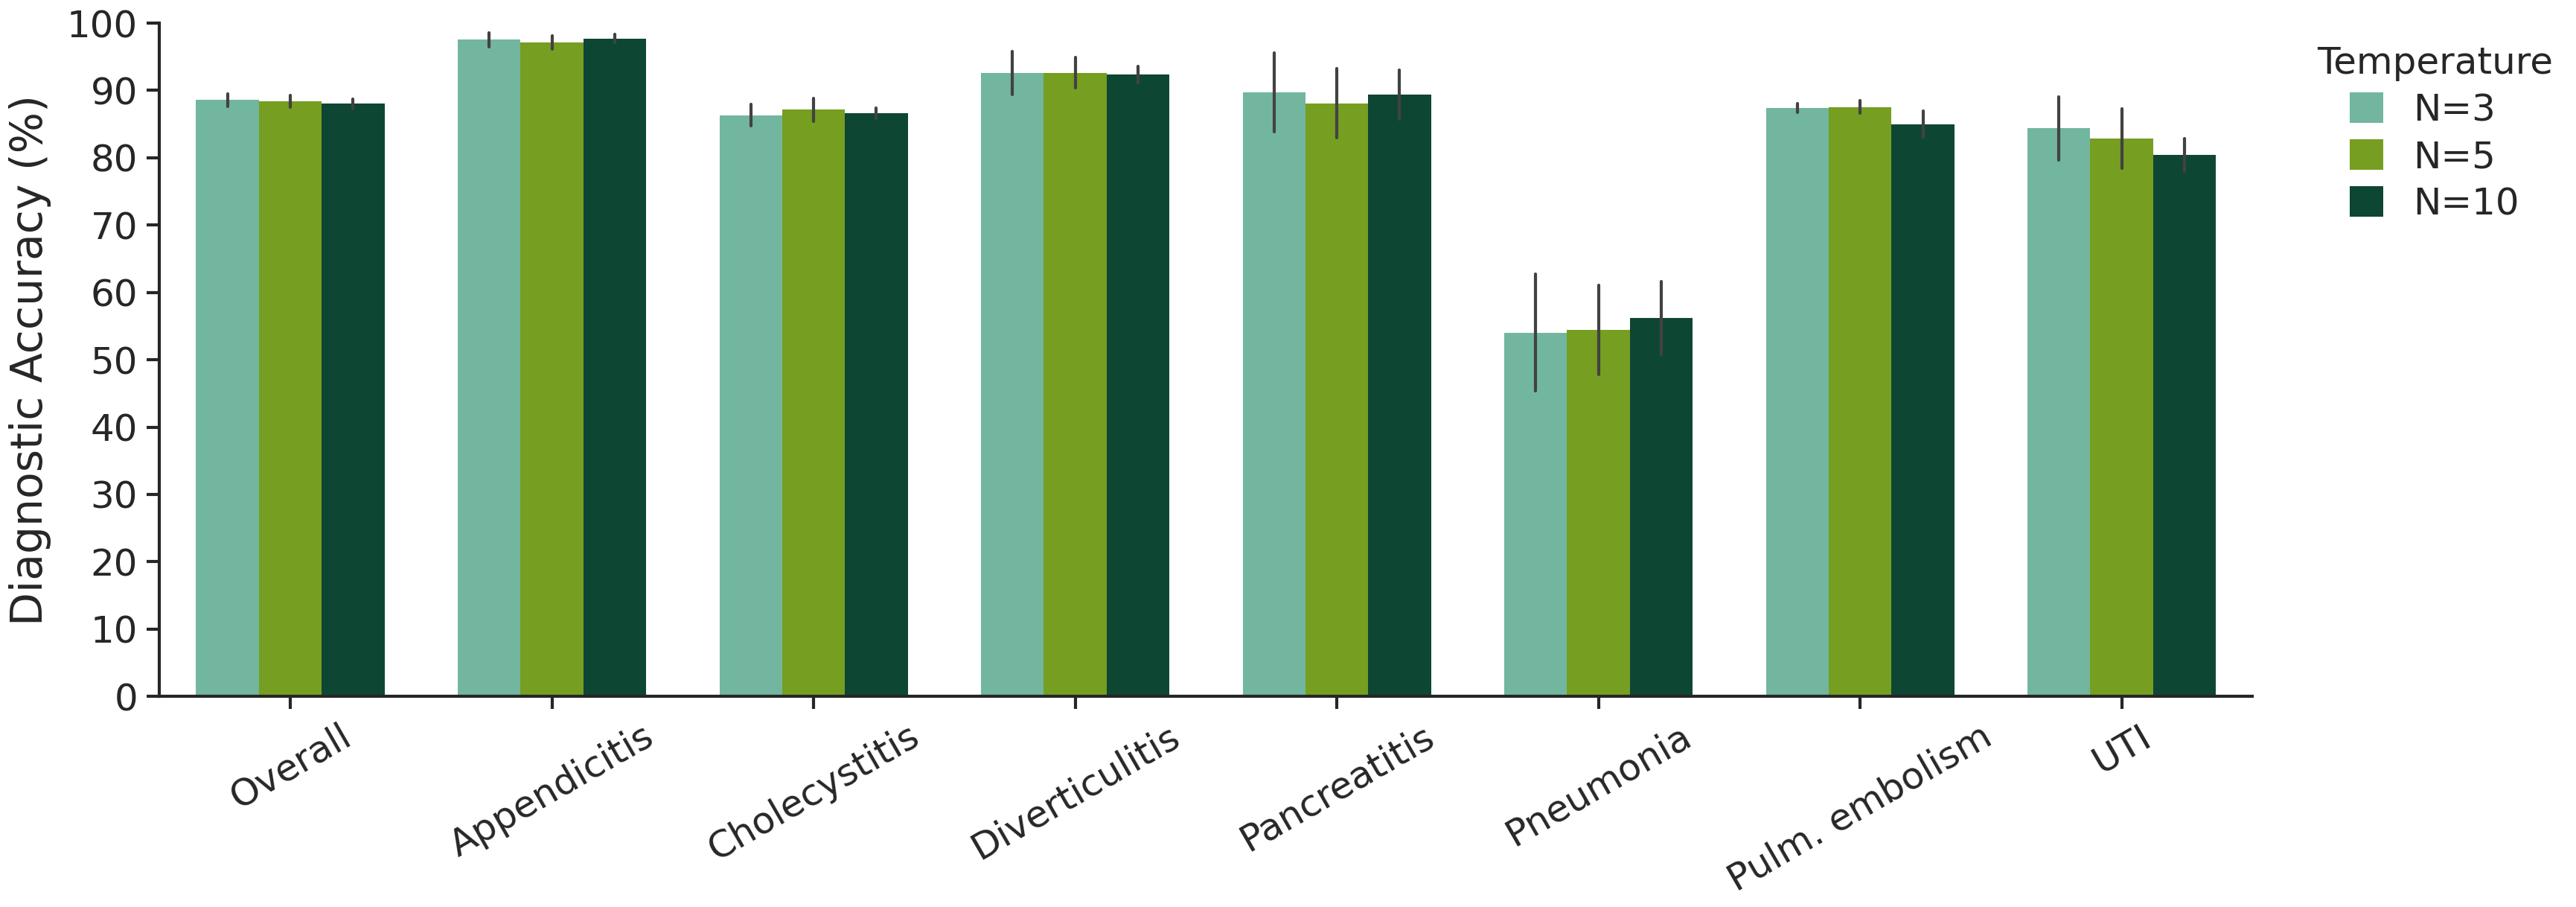

In [ ]:
# cross temperatures
import os
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator, FormatStrFormatter
import seaborn as sns

# ========== 0) Style ==========
def setup_style(double_column: bool = True):
    if double_column:
        fig_w_in = 7.09
        fig_h_in = 2.2
    else:
        fig_w_in = 3.46
        fig_h_in = 2.0

    sns.set_theme(style="white", context="paper", font_scale=1.0)

    plt.rcParams.update({
        "figure.figsize": (fig_w_in, fig_h_in),
        "figure.dpi": 600,
        "savefig.dpi": 600,
        "savefig.bbox": "tight",
        "savefig.pad_inches": 0.02,

        "font.family": "sans-serif",
        "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans", "Liberation Sans"],
        "pdf.fonttype": 42,
        "ps.fonttype": 42,

        "font.size": 7,
        "axes.labelsize": 7,
        "axes.titlesize": 7,
        "xtick.labelsize": 6,
        "ytick.labelsize": 6,
        "legend.fontsize": 6,
        "legend.title_fontsize": 6,

        "axes.spines.top": False,
        "axes.spines.right": False,
        "xtick.direction": "out",
        "ytick.direction": "out",
        "xtick.major.width": 0.5,
        "ytick.major.width": 0.5,
        "xtick.minor.width": 0.4,
        "ytick.minor.width": 0.4,
        "xtick.major.size": 2.0,
        "ytick.major.size": 2.0,
        "xtick.minor.size": 1.5,
        "ytick.minor.size": 1.5,
        "axes.linewidth": 0.5,
        "patch.edgecolor": "none",
        "patch.linewidth": 0.0,

        "axes.grid": False,
        "figure.autolayout": False,
        "mathtext.default": "regular",
        "axes.titlepad": 3,
        "axes.labelpad": 2.5,
    })

setup_style(double_column=True)

# ========== 1) Constants and paths ==========
DATASET_NAME_MAP = {
    "appendicitis": "Appendicitis",
    "cholecystitis": "Cholecystitis",
    "diverticulitis": "Diverticulitis",
    "pancreatitis": "Pancreatitis",
    "pneumonia": "Pneumonia",
    "pulmonary_embolism": "Pulm. embolism",
    "uti": "UTI",
}
# DATASET_NAME_MAP = {
#     "vivabench_pubmed": "vivabench_pubmed",
# }
ALL_DATASETS = list(DATASET_NAME_MAP.keys())

GROUPS = [
        {
        "group_label": "GLM-4.5-Air",
        "plots_base_dir": "/mnt/bulk-sirius/lizhang/LiWS/Medical_Llama_Agents/data/plots/63/63.10/63.10_N",
        "models": [
            {
                "label": "N=3",
                "dir": "/mnt/bulk-sirius/lizhang/LiWS/Medical_Llama_Agents/data/evaluation_logs/63/3runs/63.10",
                "color": "#66c2a4",
            },
            {
                "label": "N=5",
                "dir": "/mnt/bulk-sirius/lizhang/LiWS/Medical_Llama_Agents/data/evaluation_logs/63/5runs/63.10",
                "color": "#7EB30B",
            },
            {
                "label": "N=10",
                "dir": "/mnt/bulk-sirius/lizhang/LiWS/Medical_Llama_Agents/data/evaluation_logs/63/10runs_63_104/63.10",
                "color": "#054F37",
            },
        ],
    },
]



# ========== 2) Load multiple runs for one model ==========
def load_model_runs(model_label, raw_dir):
    all_runs_data = []

    # Individual subdatasets
    for internal_name in ALL_DATASETS:
        agg_file_path = os.path.join(raw_dir, f"{internal_name}_multi_run.jsonl")
        if not os.path.exists(agg_file_path):
            print(f"  警告: 文件 {agg_file_path} 未找到，跳过 {internal_name}")
            continue

        df_agg = pd.read_json(agg_file_path, lines=True)
        if df_agg.empty or "runs" not in df_agg.columns:
            continue

        num_runs = len(df_agg["runs"].iloc[0])
        for i in range(num_runs):
            run_col = f"run_{i+1}_decision"
            df_agg[run_col] = df_agg["runs"].apply(
                lambda runs: runs[i]["decision"] if len(runs) > i else None
                # lambda runs: runs[i]["effective_decision"] if len(runs) > i else None
            )
            accuracy = df_agg[run_col].mean() * 100
            all_runs_data.append({
                "Dataset": DATASET_NAME_MAP[internal_name],
                "Accuracy": accuracy,
                "Run": i + 1,
                "Model": model_label,
            })

    # Overall
    all_agg_dfs = []
    for internal_name in ALL_DATASETS:
        fp = os.path.join(raw_dir, f"{internal_name}_multi_run.jsonl")
        if os.path.exists(fp):
            all_agg_dfs.append(pd.read_json(fp, lines=True))

    if all_agg_dfs:
        df_overall_agg = pd.concat(all_agg_dfs, ignore_index=True)
        num_runs_overall = len(df_overall_agg["runs"].iloc[0])

        for i in range(num_runs_overall):
            run_col = f"run_{i+1}_decision"
            df_overall_agg[run_col] = df_overall_agg["runs"].apply(
                lambda runs: runs[i]["decision"] if len(runs) > i else None
                # lambda runs: runs[i]["effective_decision"] if len(runs) > i else None
            )
            accuracy = df_overall_agg[run_col].mean() * 100
            all_runs_data.append({
                "Dataset": "Overall",
                "Accuracy": accuracy,
                "Run": i + 1,
                "Model": model_label,
            })

    return pd.DataFrame(all_runs_data)

# ========== 3) Aggregate multiple models ==========
for group_cfg in GROUPS:
    group_label = group_cfg["group_label"]
    plots_base_dir = group_cfg["plots_base_dir"]
    os.makedirs(plots_base_dir, exist_ok=True)
    models = group_cfg["models"]

    print(f"\n===== Processing group: {group_label} =====")
    ############T0.01 vs T0.3###################
    # dir_t001 = next(m["dir"] for m in models if m["label"] == "T=0.01")
    # dir_t03 = next(m["dir"] for m in models if m["label"] == "T=0.3")

    # df_temp_test, df_temp_pairs = paired_temperature_comparison(
    #     dir_t001,
    #     dir_t03,
    #     label_a="T=0.01",
    #     label_b="T=0.3",
    #     decision_key="decision",
    #     n_boot=5000,
    #     random_state=42,
    # )

    # for col in ["Accuracy_diff_pp", "CI95_low_pp", "CI95_high_pp", "Permutation_p_one_sided", "Wilcoxon_p_one_sided"]:
    #     df_temp_test[col] = df_temp_test[col].round(4)

    # temp_test_path = os.path.join(plots_base_dir, "temperature_T001_vs_T03_paired_test.csv")
    # df_temp_test.to_csv(temp_test_path, index=False)

    # print(df_temp_test)
    # print(f"T=0.01 vs T=0.3 paired test saved to: {temp_test_path}")
    ###############################################

    all_model_dfs = []

    for model_cfg in models:
        print(f"正在加载 {model_cfg['label']} ...")
        df_model = load_model_runs(model_cfg["label"], model_cfg["dir"])
        if not df_model.empty:
            all_model_dfs.append(df_model)

    if not all_model_dfs:
        raise ValueError("没有成功加载任何 model 的结果，请检查路径。")

    df_combined = pd.concat(all_model_dfs, ignore_index=True)

    dataset_order = ["Overall"] + [name for name in DATASET_NAME_MAP.values()]
    df_combined["Dataset"] = df_combined["Dataset"].astype(str).str.strip()
    df_combined["Dataset"] = pd.Categorical(
        df_combined["Dataset"],
        categories=dataset_order,
        ordered=True
    )
    df_combined = df_combined.sort_values("Dataset")

    model_order = [m["label"] for m in models]

    df_combined["Model"] = pd.Categorical(
        df_combined["Model"],
        categories=model_order,
        ordered=True
    )

    # ========== Additional export: accuracy for each model (% +/- SD) ==========
    all_model_summary_dfs = []

    for model_cfg in models:
        print(f"正在计算 bootstrap CI for {model_cfg['label']} ...")
        df_model_summary = load_model_summary_with_case_bootstrap(
            model_cfg["label"],
            model_cfg["dir"]
        )
        if not df_model_summary.empty:
            all_model_summary_dfs.append(df_model_summary)

    if not all_model_summary_dfs:
        raise ValueError("没有成功生成任何 bootstrap summary，请检查路径。")

    df_summary_boot = pd.concat(all_model_summary_dfs, ignore_index=True)

    dataset_order = ["Overall"] + [name for name in DATASET_NAME_MAP.values()]
    model_order = [m["label"] for m in models]

    df_summary_boot["Dataset"] = pd.Categorical(
        df_summary_boot["Dataset"].astype(str).str.strip(),
        categories=dataset_order,
        ordered=True
    )

    df_summary_boot["Model"] = pd.Categorical(
        df_summary_boot["Model"],
        categories=model_order,
        ordered=True
    )

    df_summary_boot = df_summary_boot.sort_values(["Dataset", "Model"]).reset_index(drop=True)

    for col in ["Accuracy_mean", "Accuracy_sd", "CI95_low", "CI95_high"]:
        df_summary_boot[col] = df_summary_boot[col].round(2)

    # Create display columns: xx.xx +/- yy.yy
    df_summary_boot["Accuracy (% ± SD)"] = (
        df_summary_boot["Accuracy_mean"].map(lambda x: f"{x:.2f}")
        + " ± "
        + df_summary_boot["Accuracy_sd"].fillna(0).map(lambda x: f"{x:.2f}")
    )

    df_summary_boot["Accuracy (%; 95% CI)"] = (
        df_summary_boot["Accuracy_mean"].map(lambda x: f"{x:.2f}")
        + " ("
        + df_summary_boot["CI95_low"].map(lambda x: f"{x:.2f}")
        + "–"
        + df_summary_boot["CI95_high"].map(lambda x: f"{x:.2f}")
        + ")"
    )

    summary_boot_csv_path = os.path.join(plots_base_dir, "accuracy_summary_multi_T_bootstrap_CI.csv")
    df_summary_boot.to_csv(summary_boot_csv_path, index=False)

    print(f"case-level bootstrap CI 汇总已保存到: {summary_boot_csv_path}")
    # display(df_summary_boot)


    # ========== 4) Plot ==========
    fig, ax = plt.subplots()

    color_palette = {m["label"]: m["color"] for m in models}

    ax = sns.barplot(
        data=df_combined,
        x="Dataset",
        y="Accuracy",
        hue="Model",
        hue_order=model_order,
        palette=color_palette,
        errorbar="sd",
        capsize=0,
        err_kws={"linewidth": 0.5},
        width=0.72,
        linewidth=0,
        edgecolor="none",
        ax=ax,
    )

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(False)
    for spine in ["left", "bottom"]:
        ax.spines[spine].set_linewidth(0.5)

    ax.tick_params(
        axis="both",
        which="major",
        width=0.5,
        length=2.0,
        direction="out",
        top=False,
        right=False,
        bottom=True,
        left=True,
        pad=1.5,
    )

    ax.set_xlabel("")
    ax.set_ylabel("Diagnostic Accuracy (%)")

    ymin = max(0, df_combined["Accuracy"].min() - 5)
    ax.set_ylim(0, 100.0)
    ax.yaxis.set_major_locator(MultipleLocator(10))
    ax.yaxis.set_major_formatter(FormatStrFormatter("%.0f"))

    ax.tick_params(axis="x", labelrotation=30)

    handles, labels = ax.get_legend_handles_labels()
    ax.legend(
        handles=handles,
        labels=labels,
        title="Temperature",
        bbox_to_anchor=(1.02, 1.0),
        loc="upper left",
        frameon=False,
        handlelength=0.9,
        handleheight=0.9,
        borderaxespad=0.2,
        labelspacing=0.3,
        columnspacing=0.8,
    )

    plt.tight_layout(rect=[0, 0, 0.84, 1])

    # ========== 5) Save ==========
    os.makedirs(plots_base_dir, exist_ok=True)
    out_svg = os.path.join(plots_base_dir, "accuracy_comparison_multi_models.svg")
    out_png = os.path.join(plots_base_dir, "accuracy_comparison_multi_models.png")
    out_pdf = os.path.join(plots_base_dir, "accuracy_comparison_multi_models.pdf")

    plt.savefig(out_svg, format="svg", bbox_inches="tight")
    plt.savefig(out_png, format="png", bbox_inches="tight")
    plt.savefig(out_pdf, format="pdf", bbox_inches="tight")

    print(f"多模型分组条形图已保存到: {plots_base_dir}")
    # plt.show()
    # plt.close()


In [16]:
def analyze_threshold_performance(
    df: pd.DataFrame, 
    score_column: str, 
    threshold: float,
    greater_is_better: bool = True
) -> dict:
    """
    Analyze accuracy and coverage after filtering data by a given confidence score and threshold.

    Args:
        df (pd.DataFrame): Master DataFrame containing all data.
        score_column (str): The column name of the confidence score used for filtering
                            (e.g., 'Quantitative_Score', 'Semantic_Score').
        threshold (float): Confidence threshold used for filtering.
        greater_is_better (bool): Score direction. True means higher scores are better,
                                  and False means lower scores are better.

    Returns:
        dict: Dictionary containing detailed analysis results.
    """
    
    # --- 1. Filter data by threshold ---
    if greater_is_better:
        filtered_df = df[df[score_column] >= threshold]
    else:
        # For metrics such as redundancy, where lower values are better
        filtered_df = df[df[score_column] <= threshold]

    # --- 2. Initialize result storage ---
    results = {
        'score_column': score_column,
        'threshold': threshold,
        'greater_is_better': greater_is_better,
        'by_dataset': {},
        'overall': {}
    }

    # --- 3. Calculate performance for each individual dataset ---
    # Get all dataset names present in the data
    datasets_in_df = df['dataset'].unique()
    
    for dataset in datasets_in_df:
        # Get this dataset from both the original and filtered DataFrames
        original_subset = df[df['dataset'] == dataset]
        filtered_subset = filtered_df[filtered_df['dataset'] == dataset]

        # Calculate the number and proportion of retained records (coverage)
        retained_count = len(filtered_subset)
        total_count = len(original_subset)
        coverage = retained_count / total_count if total_count > 0 else 0
        # coverage_ci_lower, coverage_ci_upper = compute_wilson_ci(retained_count, total_count)
        
        # Calculate accuracy after filtering.
        if retained_count > 0:
            accuracy = filtered_subset['final_decision'].mean()
            correct_retained_count = int(filtered_subset['final_decision'].sum())
            # accuracy_ci_lower, accuracy_ci_upper = compute_wilson_ci(correct_retained_count, retained_count)
        else:
            accuracy = np.nan
            correct_retained_count = 0
            # accuracy_ci_lower, accuracy_ci_upper = np.nan, np.nan


        results['by_dataset'][dataset] = {
            'accuracy': accuracy,
            # 'accuracy_ci_lower': accuracy_ci_lower,
            # 'accuracy_ci_upper': accuracy_ci_upper,
            'correct_retained_count': correct_retained_count,
            'retained_count': retained_count,
            'total_count': total_count,
            'coverage': coverage,
            # 'coverage_ci_lower': coverage_ci_lower,
            # 'coverage_ci_upper': coverage_ci_upper,
        }

        
    # --- 4. Calculate overall performance ---
    overall_total_count = len(df)
    overall_retained_count = len(filtered_df)
    overall_coverage = overall_retained_count / overall_total_count if overall_total_count > 0 else 0
    # overall_coverage_ci_lower, overall_coverage_ci_upper = compute_wilson_ci(
    #     overall_retained_count,
    #     overall_total_count
    # )
    
    if overall_retained_count > 0:
        overall_accuracy = filtered_df['final_decision'].mean()
        overall_correct_retained_count = int(filtered_df['final_decision'].sum())
        # overall_accuracy_ci_lower, overall_accuracy_ci_upper = compute_wilson_ci(
        #     overall_correct_retained_count,
        #     overall_retained_count
        # )
    else:
        overall_accuracy = np.nan
        overall_correct_retained_count = 0
        # overall_accuracy_ci_lower, overall_accuracy_ci_upper = np.nan, np.nan


    results['overall'] = {
        'accuracy': overall_accuracy,
        # 'accuracy_ci_lower': overall_accuracy_ci_lower,
        # 'accuracy_ci_upper': overall_accuracy_ci_upper,
        'correct_retained_count': overall_correct_retained_count,
        'retained_count': overall_retained_count,
        'total_count': overall_total_count,
        'coverage': overall_coverage,
        # 'coverage_ci_lower': overall_coverage_ci_lower,
        # 'coverage_ci_upper': overall_coverage_ci_upper,
    }
    
    return results


# Add parameters before the combined-plot cell
score_column = "Consistency_Dx"
threshold = 0.9
greater_is_better = True

In [17]:
# Step 3：Build the summary DataFrame shared by Panels A and B

summary_rows = []

for group_cfg in GROUPS:
    group_label = group_cfg["group_label"]

    for model_cfg in group_cfg["models"]:
        temp_label = model_cfg["label"]
        color = model_cfg["color"]

        # ---------- full coverage accuracy ----------
        df_model = load_model_runs(temp_label, model_cfg["dir"])
        df_overall = df_model[
            df_model["Dataset"].astype(str).str.strip().eq("Overall")
        ].copy()

        if df_overall.empty:
            continue

        full_accuracy_mean = df_overall["Accuracy"].mean()
        full_accuracy_sd = df_overall["Accuracy"].std()

        # ---------- threshold-filtered accuracy / coverage ----------
        csv_path = os.path.join(model_cfg["dir"], "master_feature_dataframe.csv")

        if not os.path.exists(csv_path):
            print(f"Missing csv: {group_label} | {temp_label} | {csv_path}")
            filtered_accuracy = np.nan
            coverage = np.nan
            retained_count = np.nan
            total_count = np.nan
        else:
            df_feat = pd.read_csv(csv_path)


            res = analyze_threshold_performance(
                df=df_feat,
                score_column=score_column,
                threshold=threshold,
                greater_is_better=greater_is_better,
            )

            filtered_accuracy = res["overall"]["accuracy"] * 100
            coverage = res["overall"]["coverage"] * 100
            retained_count = res["overall"]["retained_count"]
            total_count = res["overall"]["total_count"]

        summary_rows.append({
            "Group": group_label,
            "Temperature": temp_label,
            "Color": color,
            "Full_accuracy_mean": full_accuracy_mean,
            "Full_accuracy_sd": full_accuracy_sd,
            "Filtered_accuracy": filtered_accuracy,
            "Coverage": coverage,
            "Retained_count": retained_count,
            "Total_count": total_count,
        })

df_selective = pd.DataFrame(summary_rows)

group_order = [g["group_label"] for g in GROUPS]
temp_order = []
for g in GROUPS:
    for m in g["models"]:
        if m["label"] not in temp_order:
            temp_order.append(m["label"])

df_selective["Group"] = pd.Categorical(
    df_selective["Group"],
    categories=group_order,
    ordered=True,
)
df_selective["Temperature"] = pd.Categorical(
    df_selective["Temperature"],
    categories=temp_order,
    ordered=True,
)

df_selective = df_selective.sort_values(["Group", "Temperature"]).reset_index(drop=True)

display(df_selective)



,Group,Temperature,Color,Full_accuracy_mean,Full_accuracy_sd,Filtered_accuracy,Coverage,Retained_count,Total_count
0,GLM-4.5-Air,N=3,#66c2a4,88.566243,0.960345,97.543860,51.724138,285,551
1,GLM-4.5-Air,N=5,#7EB30B,88.421053,0.874163,98.897059,49.364791,272,551
2,GLM-4.5-Air,N=10,#054F37,88.003630,0.757591,98.886827,48.911071,539,1102


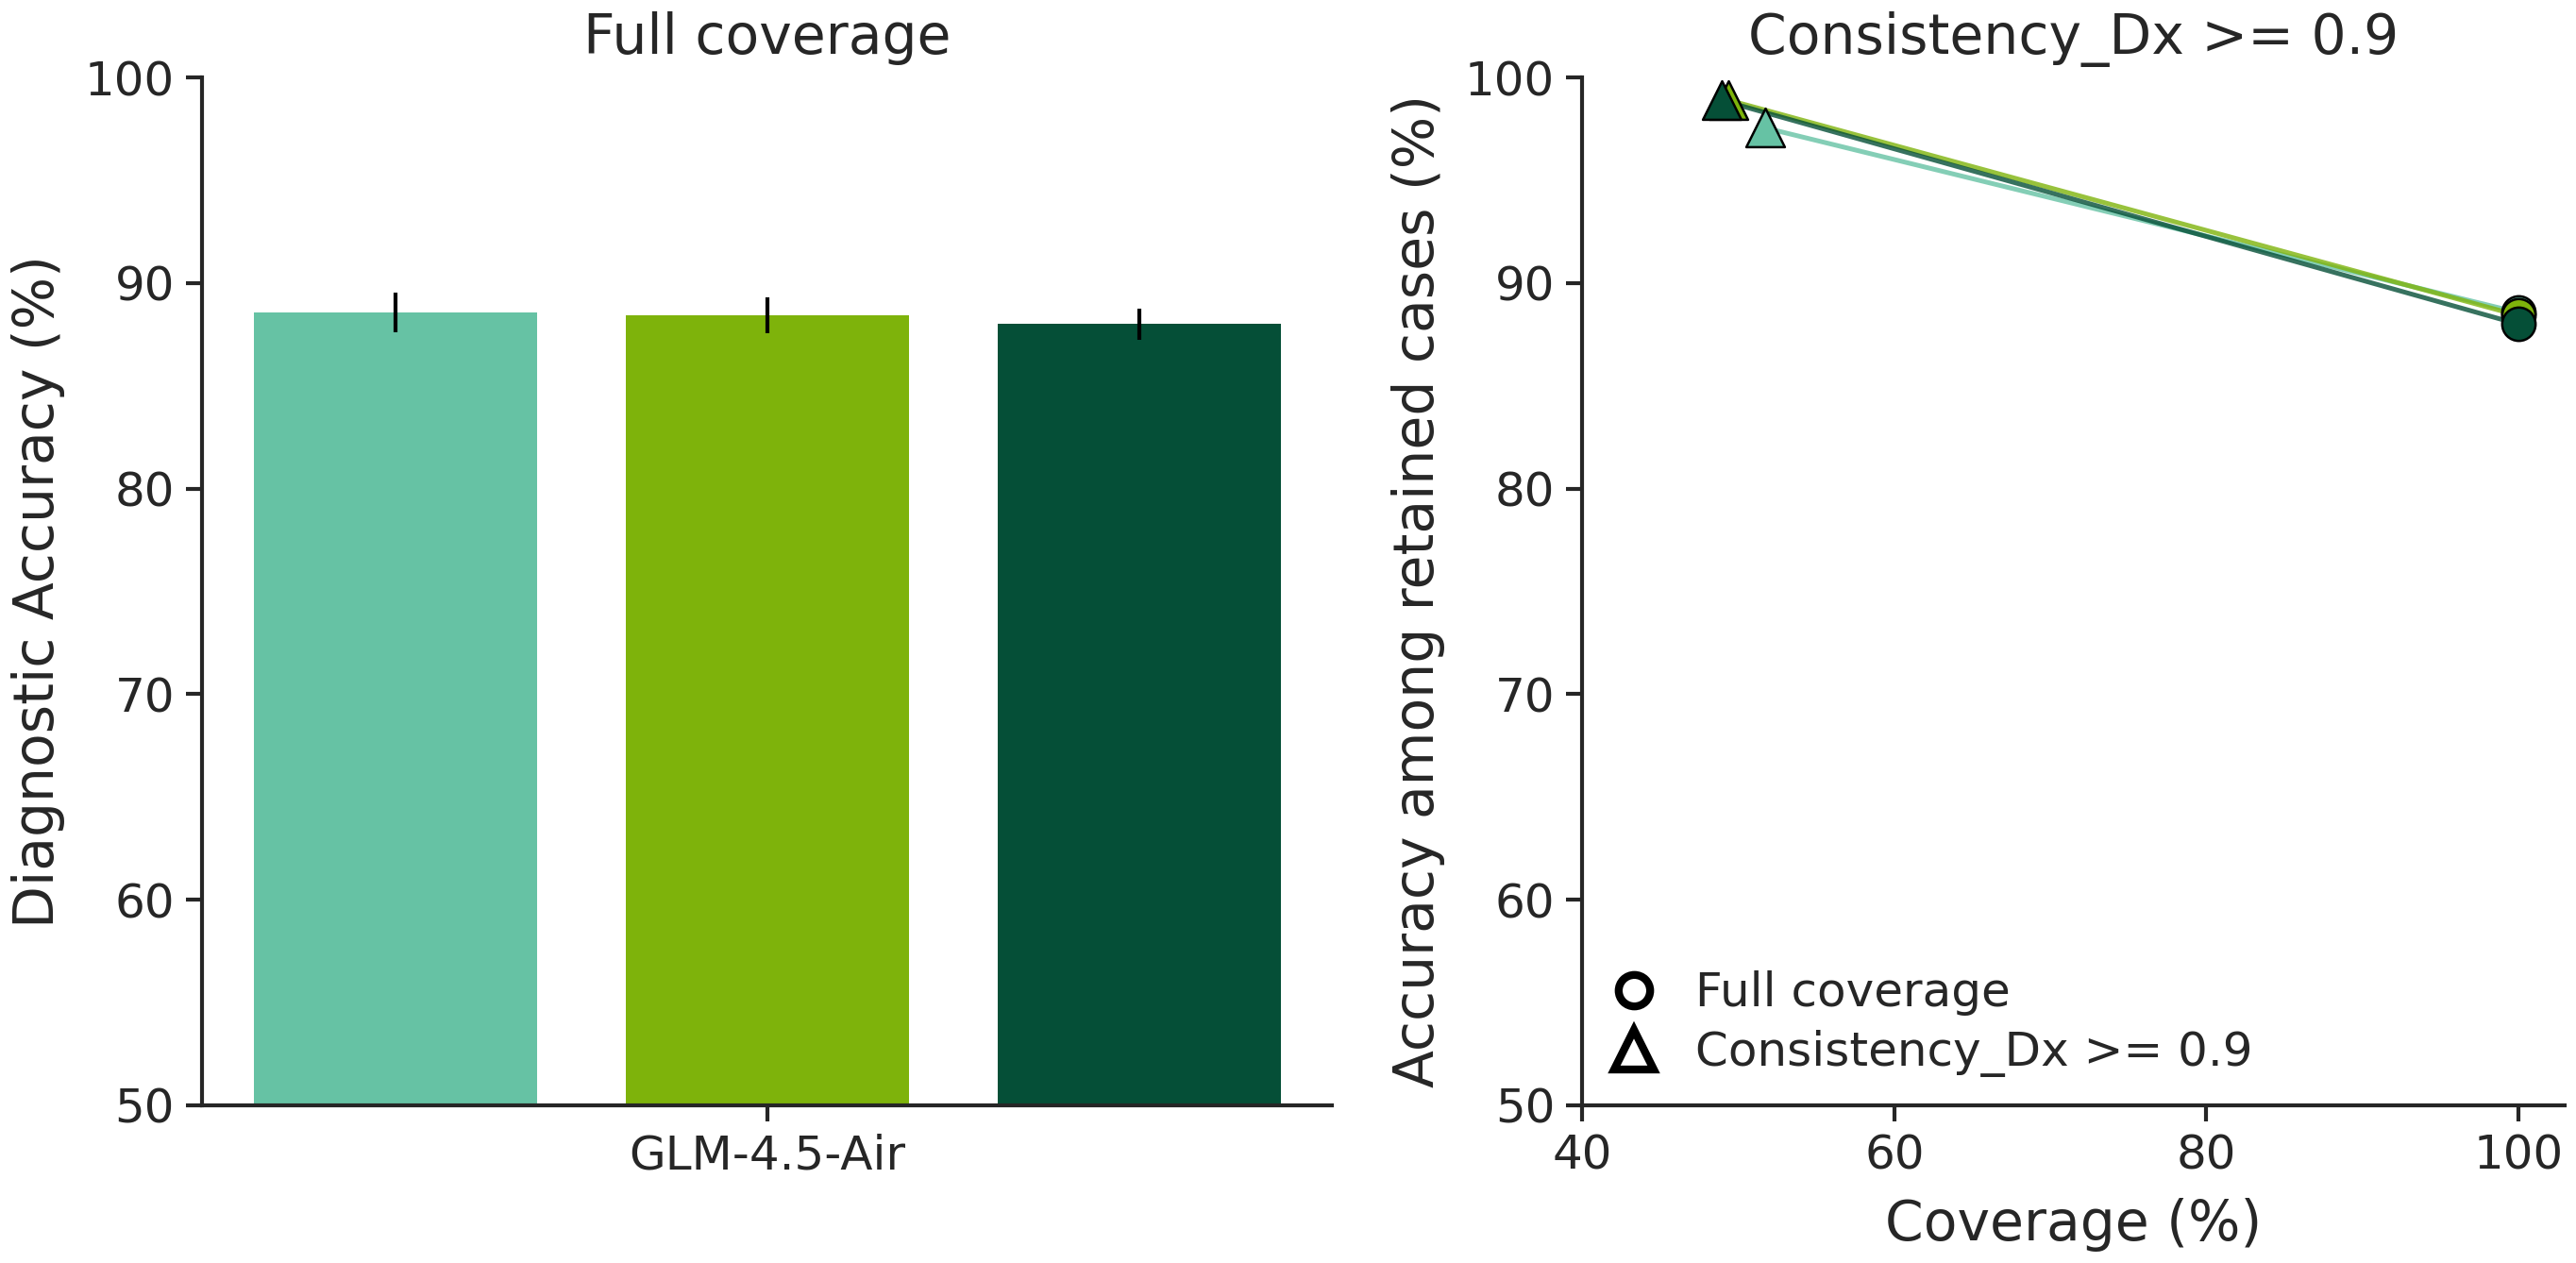

In [20]:
''''
Step 4: Plot Panel A + Panel B

Panel A is the original Overall accuracy bar plot; Panel B shows the circle/full-coverage and triangle/filtered operating points.
'''
import matplotlib.patches as mpatches


fig, axes = plt.subplots(
    1, 2,
    figsize=(120/25.4, 2.4),
    gridspec_kw={"width_ratios": [1.15, 1.0]}
)

ax_a, ax_b = axes

# ===================== Panel A: Full coverage bar plot =====================
bar_width = 0.08
group_gap = 0.12 #0.34
x_cursor = 0.0
intra_gap = 0.025
group_centers = []

for group in group_order:
    xs_this_group = []

    df_g = df_selective[df_selective["Group"] == group]

    for j, (_, row) in enumerate(df_g.iterrows()):
        # x = x_cursor + j * bar_width
        x = x_cursor + j * (bar_width + intra_gap)
        xs_this_group.append(x)

        ax_a.bar(
            x,
            row["Full_accuracy_mean"],
            width=bar_width,
            color=row["Color"],
            edgecolor="none",
            linewidth=0,
            yerr=row["Full_accuracy_sd"],
            error_kw={
                "elinewidth": 0.5,
                "capsize": 0,
                "ecolor": "black",
            },
        )

    if xs_this_group:
        group_centers.append(np.mean(xs_this_group))

    # x_cursor += len(df_g) * bar_width + group_gap
    x_cursor += len(df_g) * (bar_width + intra_gap) + group_gap

temp_legend_colors = ["#eeeeee", "#bbbbbb", "#777777", "#525252"]

temp_handles = [
    mpatches.Patch(color=temp_legend_colors[i], label=temp)
    for i, temp in enumerate(temp_order)
]

# ax_a.legend(
#     handles=temp_handles,
#     title="Temperature",
#     frameon=False,
#     loc="upper left",
#     bbox_to_anchor=(0.02, 1.05),
#     handlelength=0.9,
#     handleheight=0.9,
#     borderaxespad=0.2,
#     labelspacing=0.3,
# )

ax_a.set_xticks(group_centers)
ax_a.set_xticklabels(group_order, rotation=0)
ax_a.set_xlabel("")
ax_a.set_ylabel("Diagnostic Accuracy (%)")
ax_a.set_ylim(50, 100)
ax_a.yaxis.set_major_locator(MultipleLocator(10))
ax_a.yaxis.set_major_formatter(FormatStrFormatter("%.0f"))
ax_a.set_title("Full coverage")


# ===================== Panel B: Selective prediction =====================
for _, row in df_selective.iterrows():
    color = row["Color"]

    full_x = 100.0
    full_y = row["Full_accuracy_mean"]

    filtered_x = row["Coverage"]
    filtered_y = row["Filtered_accuracy"]

    if pd.isna(filtered_x) or pd.isna(filtered_y):
        continue

    # connection line
    ax_b.plot(
        [full_x, filtered_x],
        [full_y, filtered_y],
        color=color,
        linewidth=0.6,
        alpha=0.8,
        zorder=1,
    )

    # full coverage baseline
    ax_b.scatter(
        full_x,
        full_y,
        marker="o",
        s=18,
        color=color,
        edgecolor="black",
        linewidth=0.3,
        zorder=3,
    )

    # threshold-filtered point
    ax_b.scatter(
        filtered_x,
        filtered_y,
        marker="^",
        s=24,
        color=color,
        edgecolor="black",
        linewidth=0.3,
        zorder=4,
    )

ax_b.set_xlabel("Coverage (%)")
ax_b.set_ylabel("Accuracy among retained cases (%)")
ax_b.set_xlim(40, 103)
ax_b.set_ylim(50, 100)
ax_b.xaxis.set_major_locator(MultipleLocator(20))
ax_b.yaxis.set_major_locator(MultipleLocator(10))
ax_b.xaxis.set_major_formatter(FormatStrFormatter("%.0f"))
ax_b.yaxis.set_major_formatter(FormatStrFormatter("%.0f"))
ax_b.set_title(f"{score_column} >= {threshold}")


# ===================== Shared styling =====================
for ax in axes:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    for spine in ["left", "bottom"]:
        ax.spines[spine].set_linewidth(0.5)

    ax.grid(False)
    ax.tick_params(
        axis="both",
        which="major",
        width=0.5,
        length=2.0,
        direction="out",
        top=False,
        right=False,
        bottom=True,
        left=True,
        pad=1.5,
    )

# marker legend for Panel B
marker_handles = [
    plt.Line2D(
        [0], [0],
        marker="o",
        color="none",
        markerfacecolor="white",
        markeredgecolor="black",
        markersize=4,
        label="Full coverage",
    ),
    plt.Line2D(
        [0], [0],
        marker="^",
        color="none",
        markerfacecolor="white",
        markeredgecolor="black",
        markersize=5,
        label=f"{score_column} >= {threshold}",
    ),
]

ax_b.legend(
    handles=marker_handles,
    frameon=False,
    loc="lower left",
    handlelength=1.0,
    borderaxespad=0.2,
    labelspacing=0.3,
)

plt.tight_layout()

combined_plot_dir = "/mnt/bulk-sirius/lizhang/LiWS/Medical_Llama_Agents/data/plots/63/63.10/63.10_N"
os.makedirs(combined_plot_dir, exist_ok=True)

out_svg = os.path.join(combined_plot_dir, "overall_accuracy_selective_prediction.svg")
out_png = os.path.join(combined_plot_dir, "overall_accuracy_selective_prediction.png")
out_pdf = os.path.join(combined_plot_dir, "overall_accuracy_selective_prediction.pdf")

plt.savefig(out_svg, format="svg", bbox_inches="tight")
plt.savefig(out_png, format="png", bbox_inches="tight")
plt.savefig(out_pdf, format="pdf", bbox_inches="tight")

plt.show()
plt.close()
